In [1]:
import sys
import os
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import modul internal proyek Anda
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import load_stock_data, dataset_splitting
from src.visualizer import plot_interactive_candlestick
from src.features import create_features          # Sesuaikan nama fungsi jika berbeda
from src.label import create_labels                # Sesuaikan nama fungsi jika berbeda
from src.risk_manager import evaluate_trade_risk   # Otak manajemen risiko kuantitatif
from src.backtest import WalkForwardBacktester

print("✓ Seluruh modul berhasil diimpor.")

✓ Seluruh modul berhasil diimpor.


In [2]:
# 1. Unduh Data Historis Saham
ticker_target = "BBRI.JK"
IN_SAMPLE_START = "2014-11-01"
IN_SAMPLE_END = '2023-12-31'    # Data latih: 2015 - 2023
OOS_START = '2024-01-01'        # Data uji: 2024 - 2025
OOS_END = '2025-12-31'
TODAY = datetime.now().strftime('%Y-%m-%d')
end_date_today = datetime.now().strftime('%Y-%m-%d')

df = load_stock_data(ticker=ticker_target, start_date=IN_SAMPLE_START, end_date=TODAY)

Mengunduh data terbaru untuk BBRI.JK dari Yahoo Finance...
Berhasil memuat 2915 baris data untuk BBRI.JK.
Info Data Cleaning: Menghapus 73 baris data (NaN atau Volume 0).
Berhasil memuat 2842 baris data bersih untuk BBRI.JK.


In [3]:
# 2. Replikasi Rekayasa Fitur (X) & Target Label (y)
df_features = create_features(df.copy()) # Panggil fungsi dari features.py
df_labels = create_labels(df.copy())     # Panggil fungsi dari label.py

# Ekstrak daftar kolom fitur (mengabaikan kolom NaN)
feature_cols = [col for col in df_features.columns if col not in ['Open', 'High', 'Low', 'Close', 'Volume']]

# 3. Pisahkan Data ke Fase In-Sample & Out-of-Sample menggunakan dataset_splitting
X_in, y_in_raw, X_oos, y_oos_raw, _, _ = dataset_splitting(df_features, df_labels, IN_SAMPLE_START, IN_SAMPLE_END, OOS_START, "2026-08-31")

# Bungkus dictionary target label untuk memfasilitasi 5 model
y_in_dict = {target: y_in_raw[target] for target in ['trend_slope', 'return', 'risk', 'days_to_max', 'days_to_min']}
y_oos_dict = {target: y_oos_raw[target] for target in ['trend_slope', 'return', 'risk', 'days_to_max', 'days_to_min']}

# 4. Inisialisasi & Jalankan Backtest
backtester = WalkForwardBacktester(
    ticker=ticker_target,
    min_dip_proba=1,
    min_rr_ratio=1.1,
    max_risk_pct=0.06,
    max_alloc_pct=0.5,
    max_holding_days=3,
    fee_buy=0.0015,
    fee_sell=0.0025,
    initial_capital=10_000_000.0,
)

# Jalankan simulasi pada data Out-of-Sample (2024 - 2025)
df_trades_result, df_equity_curve = backtester.run_backtest(
    X_in=X_in,
    y_in_dict=y_in_dict,
    X_oos=X_oos,
    y_oos_dict=y_oos_dict,
    df_raw_prices=df,
    feature_cols=feature_cols
)

 MEMULAI SIMULASI WALK-FORWARD ANALYSIS (BBRI.JK)
 Modal Awal: Rp10,000,000.00

[INIT] Memuat model awal dari folder models/bbri...
--------------------------------------------------
PERIODE KELOLAAN: 2024-01 | OOS: 22 Hari Bursa
--------------------------------------------------

[RETRAIN] Melatih ulang 4 model dengan data Expanding Window (2233 baris)...
[RETRAIN] Seluruh model berhasil diperbarui.

--------------------------------------------------
PERIODE KELOLAAN: 2024-02 | OOS: 18 Hari Bursa
--------------------------------------------------

[RETRAIN] Melatih ulang 4 model dengan data Expanding Window (2251 baris)...
[RETRAIN] Seluruh model berhasil diperbarui.

--------------------------------------------------
PERIODE KELOLAAN: 2024-03 | OOS: 18 Hari Bursa
--------------------------------------------------

[RETRAIN] Melatih ulang 4 model dengan data Expanding Window (2269 baris)...
[RETRAIN] Seluruh model berhasil diperbarui.

-------------------------------------------------

In [4]:
# Menampilkan grafik interaktif yang berisi Candlestick, Volume, dan Hasil Prediksi
plot_interactive_candlestick(
    df=df,               # Dataframe OHLCV saham (sesuaikan nama variabel jika berbeda)
    ticker_name=ticker_target,
    start_date="2024-01-01",  # Opsional: sesuaikan rentang zoom awal jika diperlukan
    end_date="2026-08-31",
    predictions_df=backtester.predictions_df,  # Ambil data dari objek backtester
    df_equity=df_equity_curve,           # Diambil dari output run_backtest()
    df_trades=df_trades_result,                 # Diambil dari output run_backtest()
    show_raw_buy_signals=True
)


=== DISTRIBUSI ALASAN JUAL ===


exit_reason
Time-Stop         1
EMA 5/10 Cross    1
Name: count, dtype: int64


Dalam bentuk persentase:


exit_reason
Time-Stop         50.0
EMA 5/10 Cross    50.0
Name: proportion, dtype: float64


=== DISTRIBUSI HARI UNTUK TIME-STOP ===


days_held
3    1
Name: count, dtype: int64

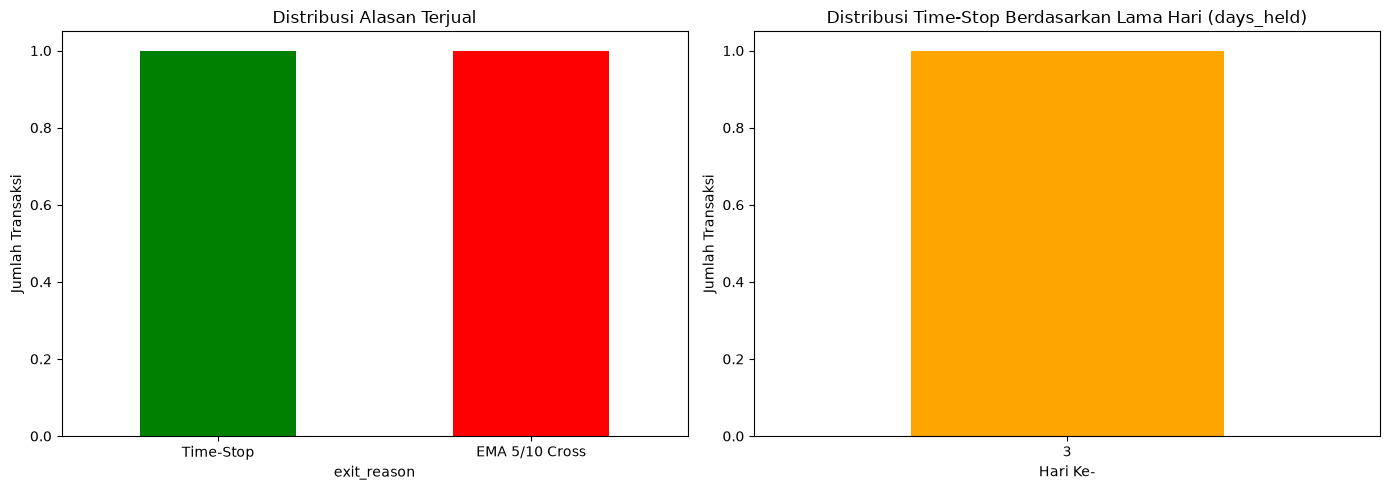

In [5]:
# 1. Melihat Distribusi Alasan Terjual (Exit Reason)
print("=== DISTRIBUSI ALASAN JUAL ===")
display(df_trades_result['exit_reason'].value_counts())
print("\nDalam bentuk persentase:")
display(df_trades_result['exit_reason'].value_counts(normalize=True) * 100)

# 2. Melihat Distribusi Hari untuk status 'Time-Stop'
print("\n=== DISTRIBUSI HARI UNTUK TIME-STOP ===")
time_stop_df = df_trades_result[df_trades_result['exit_reason'] == 'Time-Stop']
display(time_stop_df['days_held'].value_counts().sort_index())

# Opsional: Jika ingin divisualisasikan dalam bentuk grafik (Bar Chart)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Alasan Terjual
df_trades_result['exit_reason'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red', 'orange', 'grey'])
axes[0].set_title('Distribusi Alasan Terjual')
axes[0].set_ylabel('Jumlah Transaksi')
axes[0].tick_params(axis='x', rotation=0)

# Plot Hari Time-Stop
if not time_stop_df.empty:
    time_stop_df['days_held'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='orange')
    axes[1].set_title('Distribusi Time-Stop Berdasarkan Lama Hari (days_held)')
    axes[1].set_xlabel('Hari Ke-')
    axes[1].set_ylabel('Jumlah Transaksi')
    axes[1].tick_params(axis='x', rotation=0)
else:
    axes[1].set_title('Tidak Ada Transaksi Time-Stop')

plt.tight_layout()
plt.show()


In [6]:
from src.stress_test import run_stress_test_suite

# Menjalankan Monte Carlo (2.000 iterasi) + Slippage Test + Print Report + Plot Interaktif
tester, fig_mc, fig_slip = run_stress_test_suite(df_trades_result, initial_capital=10_000_000.0)

# Tampilkan visualisasi interaktif Plotly
fig_mc.show()
fig_slip.show()

         LAPORAN RESMI STRESS TEST & VALIDASI KUANTITATIF
 Modal Awal               : Rp10,000,000.00
 Eksekusi Riil Skenario 2 : Rp10,080,989.96 (+0.81%)
 Jumlah Transaksi Uji     : 2 trade (Out-of-Sample)
---------------------------------------------------------------------------
 1. UJI PERMUTASI (Sensitivitas Urutan Trade - Reshuffling)
    - Median Max Drawdown : 0.00%
    - 95th Percentile MDD : 0.00%
    - Worst-Case Absolut  : 0.00% (Bahkan jika semua loss berturut-turut)
    - Best-Case Drawdown  : 0.00%
---------------------------------------------------------------------------
 2. UJI BOOTSTRAP RESAMPLING (Proyeksi 2.000 Skenario Masa Depan)
    - Probabilitas Profit : 100.00% (Peluang modal akhir > Rp10 Juta)
    - Risk of Ruin (DD>20): 0.00%
    - Risk of Ruin (DD>50): 0.00% (Risiko kehancuran modal)
    - 95% VaR (Skenario P05): Rp10,061,851.80 (Batas kerugian terburuk 95%)
    - Median Modal Akhir  : Rp10,080,989.96
    - 95th Percentile Cap : Rp10,100,164.52
-----------

In [7]:
final_equity = df_equity_curve.iloc[-1]['total_equity']
ticker = ticker_target.lower().split('.')[0]
save_csv_path=f"../data/processed/jurnal_trading_{ticker}_{final_equity:,.2f}_{backtester.max_risk_pct}_{backtester.max_alloc_pct}_{backtester.min_rr_ratio}.csv"
df_journal = backtester.save_trade_history_to_csv(df, save_csv_path)

# Tampilkan jurnal
display(df_journal.tail(10))


[INFO] Jurnal berhasil disimpan ke: ../data/processed/jurnal_trading_bbri_10,080,989.96_0.06_0.5_1.1.csv


,Open,High,Low,Close,Volume,Keputusan,Harga Eksekusi,Lot,Value Transaksi,Invested,Sisa Cash,Total Equity
Date,,,,,,,,,,,,
2026-08-14,"3,110.00","3,150.00","3,090.00","3,120.00","118,492,200",-,0.00,0,0.00,0.00,"10,080,989.96","10,080,989.96"
2026-08-18,"3,120.00","3,140.00","3,080.00","3,080.00","153,801,000",-,0.00,0,0.00,0.00,"10,080,989.96","10,080,989.96"
2026-08-19,"3,080.00","3,100.00","3,040.00","3,080.00","101,112,000",-,0.00,0,0.00,0.00,"10,080,989.96","10,080,989.96"
2026-08-20,"3,100.00","3,140.00","3,090.00","3,140.00","156,120,300",-,0.00,0,0.00,0.00,"10,080,989.96","10,080,989.96"
2026-08-21,"3,170.00","3,250.00","3,160.00","3,230.00","349,663,900",-,0.00,0,0.00,0.00,"10,080,989.96","10,080,989.96"
2026-08-24,"3,230.00","3,240.00","3,160.00","3,180.00","151,200,300",-,0.00,0,0.00,0.00,"10,080,989.96","10,080,989.96"
2026-08-26,"3,170.00","3,170.00","3,110.00","3,130.00","159,003,300",-,0.00,0,0.00,0.00,"10,080,989.96","10,080,989.96"
2026-08-27,"3,110.00","3,150.00","3,100.00","3,150.00","164,832,300",-,0.00,0,0.00,0.00,"10,080,989.96","10,080,989.96"
2026-08-28,"3,180.00","3,200.00","3,160.00","3,190.00","135,419,900",-,0.00,0,0.00,0.00,"10,080,989.96","10,080,989.96"
